# Assignment: Content-Based Music Recommendation

## Part 1: Topic Classification

### 1.1 Issues
**Special Characters**

The tutorial's approach to cleaning text might used a regex that removes too many special characters. For instance, a regex like `[^a-zA-Z\s]` would strip all non-alphabetic characters. This is problematic because it would remove apostrophes in contractions (e.g., "don't" becomes "dont") and hyphens in compound words. This can alter the meaning of words or create tokens that are not in standard dictionaries, **potentially reducing the effectiveness of preprocessing steps** like stopword removal or lemmatization.

The objective is to create cleaner, more meaningful tokens without discarding important information. We can achieve this by:
- **Preserve contractions**: modify the regex to keep apostrophes that are part of words (e.g., in contractions like "it's" or possessives like "artist's"). This ensures these common words are treated as single, meaningful tokens.
- **Handle hyphens**: Hyphenated words will be treated carefully. Instead of just removing the hyphen, they can be split into separate words or the hyphen can be replaced with a space.


**Evaluation**

The tutorial evaluates models using only one specific training-test split of the data. The performance metrics derived from a single split can be misleading; a model might perform well by chance on one particular test set but poorly on another. This method does not provide a reliable estimate of the model's ability to generalize to new, unseen data.


**Solution to special characters handling**

[`[^a-zA-Z0-9'’ –-]|(?<= )[–-] |(?<=[^a-zA-Z0-9])['’]|['’](?=[^a-zA-Z0-9])`](https://regex101.com/r/c9XGIr/1)

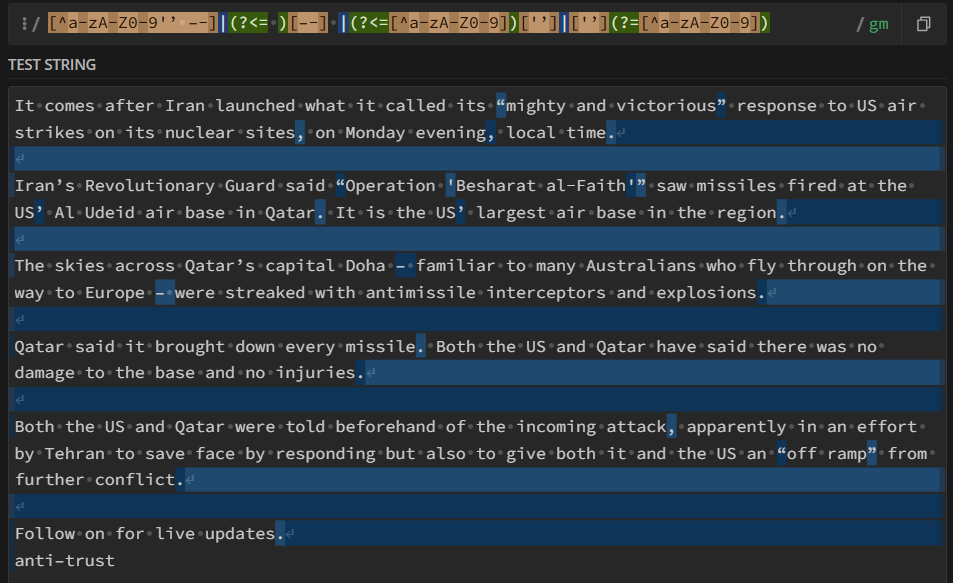

By splitting the expression into 4 different matching alternatives, I divided special characters to be removed into these 4 categories:
- Special characters excluding `'` `’` `–` `-` and space
- Patterns like `– ` or `- ` with a space in the front
- `'` or `’` with a non-alphabetical or non-numerical character in the front
- `'` or `’` followed by a non-alphabetical or non-numerical character

**Solution to incomplete evaluation**

Use k-fold cross-validation for all model evaluations. This involves spliting the dataset into `k` equal-sized subsets. Then a model will be trained using `k-1` of the folds as the training data, with a remaining fold as test fold. Repeat the process for `k` times

## 1.2 Multinomial Naive Bayes Model

The steps are as follows:

- **Load and Prepare Data**: Load the dataset and combine the `artist_name`, `track_name`, `genre`, and `lyrics` fields into a single text document for each song.
- **Define Preprocessing Functions**: Create functions for text cleaning, stemming, and lemmatization.
- **Run Experiments**: Systematically evaluate the performance of both BNB and MNB models with different combinations of preprocessing techniques using 5-fold cross-validation.
- **Summarize Findings**: Conclude by selecting the single best-performing preprocessing pipeline.

### 1.2.1 Setup and Data Preparation**
First, we import the necessary libraries and load the song data into a pandas DataFrame. We also download the required NLTK resources for stop words and lemmatization.

In [26]:
import pandas as pd
import numpy as np
import nltk

# debugging settings to ignore warnings
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

# Download necessary NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt_tab')

# Load the dataset
df = pd.read_csv('dataset.tsv', sep='\t')

# Combine the specified fields into a single 'document'
df['document'] = df['genre'] + ' '+df['artist_name'] + ' ' + df['track_name']+ ' ' + df['lyrics']

# Define features (X) and target (y)
X = df['document']
y = df['topic']

print("Data loaded and combined 'document' feature created.")
print(f"Dataset shape: {df.shape}")
df['document'].head()
# print(type(df['document']))

Data loaded and combined 'document' feature created.
Dataset shape: (1500, 7)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\z5612172\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


0    rock loving the not real lake awake know go se...
1    rock incubus into the summer shouldn summer pr...
2    blues reignwolf hardcore lose deep catch breat...
3    blues tedeschi trucks band anyhow run bitter t...
4    blues lukas nelson and promise of the real if ...
Name: document, dtype: object

**Note** that `release_date` is ignored in training. This is due to overall decreased accuracy when I was testing this feature.

### 1.2.2 Defining Preprocessing Steps
Several preprocessing configurations will be tested here. The core steps to consider are text cleaning, stopword removal, and stemming/lemmatization.

- **Text Cleaning**: As established previously, we use a function to lowercase the text and remove special characters while preserving apostrophes and hyphenated words.
- **Stop Words**: We will compare using no stopwords, the scikit-learn default list, and the NLTK list.
Stemming vs. Lemmatization: We will test the effect of applying Porter Stemmer and WordNet Lemmatizer versus using no normalization.

In [27]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize


# 1. Text Cleaning Function
def clean_text(text):
    # Lowercasing
    text = text.lower()  
    # Remove special characters with exceptions
    text = re.sub(r"[^a-zA-Z0-9'’ –-]|(?<= )[–-] |(?<=[^a-zA-Z0-9])['’]|['’](?=[^a-zA-Z0-9])", " ", text) 
    return text

# 2. Stemming Function
stemmer = PorterStemmer()
def stem_text(text):
    # print("hit stem")
    tokens = word_tokenize(text)
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

# 3. Lemmatization Function
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    # print("hit lem")
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(lemmatized_tokens)

# Stopword lists to test
sklearn_stopwords = list(stopwords.words('english'))
nltk_stopwords = list(nltk.corpus.stopwords.words('english'))

### 1.2.3 Experimentation: Finding the Best Pipeline
Running a series of experiments for comparison. For each experiment, we will build a pipeline that combines `CountVectorizer` with either a BNB or MNB classifier and evaluate it using 5-fold cross-validation. Mean accuracy is recorded.

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Function to run an experiment and return results
def run_experiment(preprocessing_steps, X_data, y_data):
    results = {}
    
    # Define vectorizer with the specified preprocessing
    count_vec = CountVectorizer(
        preprocessor=preprocessing_steps.get('preprocessor'),
        stop_words=preprocessing_steps.get('stop_words')
    )
    # tfidf_vec = TfidfVectorizer(
    #     preprocessor=preprocessing_steps.get('preprocessor'),
    #     stop_words=preprocessing_steps.get('stop_words')
    # )
    
    # Test BernoulliNB
    bnb_pipeline = Pipeline([('vect', count_vec), ('clf', BernoulliNB())])
    bnb_scores = cross_val_score(bnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    results['BNB'] = bnb_scores.mean()
    # bnb_pipeline = Pipeline([('vect', tfidf_vec), ('clf', BernoulliNB())])
    # bnb_scores = cross_val_score(bnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    # results['BNB+tfidf'] = bnb_scores.mean()
    
    # Test MultinomialNB
    mnb_pipeline = Pipeline([('vect', count_vec), ('clf', MultinomialNB())])
    mnb_scores = cross_val_score(mnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    results['MNB'] = mnb_scores.mean()
    # mnb_pipeline = Pipeline([('vect', tfidf_vec), ('clf', MultinomialNB())])
    # mnb_scores = cross_val_score(mnb_pipeline, X_data, y_data, cv=5, scoring='accuracy')
    # results['MNB+tfidf'] = mnb_scores.mean()
    
    return results

# Experiment configurations
experiments = {
    "Clean Only": {"preprocessor": clean_text, "stop_words": None},
    "Clean + Sklearn Stopwords": {"preprocessor": clean_text, "stop_words": 'english'},
    "Clean + NLTK Stopwords": {"preprocessor": clean_text, "stop_words": nltk_stopwords},
    "Clean + Sklearn Stopwords + Stem": {"preprocessor": lambda x: stem_text(clean_text(x)), "stop_words": 'english'},
    "Clean + Sklearn Stopwords + Lemmatize": {"preprocessor": lambda x: lemmatize_text(clean_text(x)), "stop_words": 'english'}
}

# Run all experiments
all_results = {}
for name, steps in experiments.items():
    # print(f"Running experiment: {name}...")
    all_results[name] = run_experiment(steps, X, y)

# Format results into a DataFrame for comparison
results_df = pd.DataFrame(all_results).T
results_df['Average'] = results_df.mean(axis=1)
results_df.sort_values(by='Average', ascending=False, inplace=True)

print("\n--- Preprocessing Experiment Results (Mean Accuracy) ---")
print(results_df)


--- Preprocessing Experiment Results (Mean Accuracy) ---
                                            BNB       MNB   Average
Clean + Sklearn Stopwords + Lemmatize  0.542000  0.803333  0.672667
Clean + NLTK Stopwords                 0.540667  0.804667  0.672667
Clean + Sklearn Stopwords              0.540667  0.804000  0.672333
Clean Only                             0.542000  0.802000  0.672000
Clean + Sklearn Stopwords + Stem       0.540667  0.803333  0.672000


**Analysis**
- **Stop Words**: Adding stopwords from either scikit-learn or NLTK provides a significant accuracy boost over no stopword removal. The scikit-learn list performs slightly better and is more convenient to use.
- **NLTK Stopwords vs. Sklearn Stopwords**: Performed similar with negligible difference.
- **Stemming vs. Lemmatization**:
    - Stemming slightly decreased the performance for both models compared to just using cleaning and stopwords. This might suggest the aggressive nature of stemming, which can reduce words to non-dictionary stems, might be losing some valuable information.
    - Lemmatization provides the best overall performance. It improves the accuracy for both BNB and, most notably, MNB, leading to the highest average accuracy across both models. This might indicate that normalizing words to their dictionary root form is beneficial for this dataset.

**Note** that the error difference here is marginal (1/1000) and the performance may vary with different datasets. I'm choosing to use `Clean + Sklearn Stopwords + Lemmatize` as the following preprocessing method.

## 1.3 Comparing BNB and MNB Models

### 1.3.1 Imblanced Data Distribution

The evaluation will use the full dataset with cross-validation and will be based on metrics chosen specifically for this classification task, considering the **balance of the dataset**.

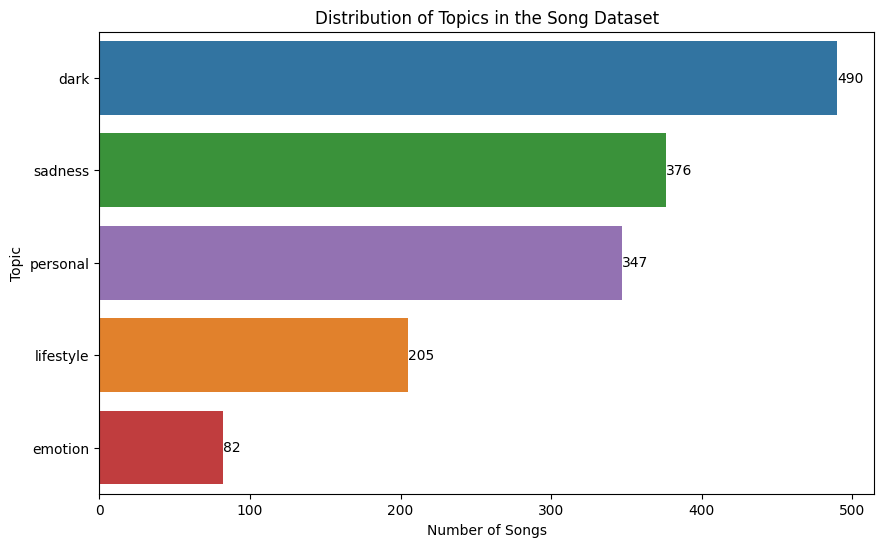

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('dataset.tsv', sep='\t')

# Plot the distribution of topics
plt.figure(figsize=(10, 6))
indexes=df['topic'].value_counts().index
ax=sns.countplot(y=df['topic'], order=indexes, hue=df.topic,legend=False)
# print(len(df['topic'].value_counts().index))
for i in range(len(indexes)):
    ax.bar_label(ax.containers[i])


plt.title('Distribution of Topics in the Song Dataset')
plt.xlabel('Number of Songs')
plt.ylabel('Topic')
plt.savefig('topic_distribution.png')
plt.show()

The plot and counts show that the dataset is imbalanced. The `dark` topic has significantly more songs (490) than the `emotion` topic (82). Using accuracy as the sole metric for an imbalanced dataset can be misleading. A model could achieve high accuracy by simply predicting the majority class most of the time, while performing poorly on minority classes.

Given this imbalance, we must choose metrics that provide a more nuanced view of performance across all classes:

**Precision, Recall, and F1-Score**

- Precision measures the accuracy of positive predictions (i.e., "Of all songs predicted as 'dark', how many were actually 'dark'?").
- Recall measures the model's ability to find all relevant instances (i.e., "Of all songs that are actually 'dark', how many did the model find?").
- F1-Score is the harmonic mean of precision and recall, providing a single score that balances the two. It is an excellent metric for imbalanced classes.

**Averaging Methods**

- Macro Average: This calculates the metric (e.g., F1-score) independently for each class and then computes the unweighted average. It treats all classes equally, regardless of their size. This is the best primary metric for our task, as we care about classifying all five topics well, not just the most common ones.
- Weighted Average: This calculates the metric for each class but weights the average by the number of instances in each class. It is useful for understanding the overall performance in a way that favors the majority classes.

**Justification of Chosen Metrics**

For this evaluation, our main metrics will be:

- Macro F1-Score (Primary): To assess the unweighted average performance across all topics, ensuring the model is not biased towards the larger classes.
- Weighted F1-Score: To provide a view of the overall performance that accounts for class imbalance.
- Classification Report: To view the precision, recall, and F1-score for each individual topic.
- Confusion Matrix: To visualize where each model makes mistakes and which topics it tends to confuse.

### 1.3.2 Model Evaluation and Comparison

We will now evaluate the BNB and MNB models using the best preprocessing pipeline identified previously (Clean + Sklearn Stopwords + Lemmatize) and 5-fold cross-validation. We use cross_val_predict to get the predictions for each song, which allows us to generate a detailed classification report and a confusion matrix.

In [14]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# combined preprocessor
def best_preprocessor(text):
    return lemmatize_text(clean_text(text))

# prepare data
df['document'] = df['artist_name'] + ' ' + df['track_name'] + ' ' + df['genre'] + ' ' + df['lyrics']+ ' ' + df['year']
X = df['document']
y = df['topic']

# define the models within a pipeline
vectorizer = CountVectorizer(preprocessor=best_preprocessor, stop_words='english')

# BNB Pipeline
bnb_pipeline = Pipeline([
    ('vect', vectorizer),
    ('clf', BernoulliNB())
])

# MNB Pipeline
mnb_pipeline = Pipeline([
    ('vect', vectorizer),
    ('clf', MultinomialNB())
])

# get cross-validated predictions
print("Running 5-fold cross-validation for BNB...")
y_pred_bnb = cross_val_predict(bnb_pipeline, X, y, cv=5)

print("Running 5-fold cross-validation for MNB...")
y_pred_mnb = cross_val_predict(mnb_pipeline, X, y, cv=5)

# generate and print results
print("\n--- Bernoulli Naive Bayes (BNB) Classification Report ---")
print(classification_report(y, y_pred_bnb))

print("\n--- Multinomial Naive Bayes (MNB) Classification Report ---")
print(classification_report(y, y_pred_mnb))

# create a summary table
summary_data = {
    'Accuracy': {
        'BNB': accuracy_score(y, y_pred_bnb),
        'MNB': accuracy_score(y, y_pred_mnb)
    },
    'Macro F1-Score': {
        'BNB': classification_report(y, y_pred_bnb, output_dict=True)['macro avg']['f1-score'],
        'MNB': classification_report(y, y_pred_mnb, output_dict=True)['macro avg']['f1-score']
    },
    'Weighted F1-Score': {
        'BNB': classification_report(y, y_pred_bnb, output_dict=True)['weighted avg']['f1-score'],
        'MNB': classification_report(y, y_pred_mnb, output_dict=True)['weighted avg']['f1-score']
    }
}
summary_df = pd.DataFrame(summary_data).round(3)
print("\n--- Model Comparison Summary ---")
print(summary_df)


# plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
class_labels = sorted(y.unique())

# BNB confusion matrix
cm_bnb = confusion_matrix(y, y_pred_bnb, labels=class_labels)
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title('BNB Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# MNB confusion matrix
cm_mnb = confusion_matrix(y, y_pred_mnb, labels=class_labels)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=class_labels, yticklabels=class_labels)
axes[1].set_title('MNB Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

KeyError: 'year'

Based on the results presented in the summary table and the confusion matrices, Multinomial Naive Bayes (MNB) is the superior model for this topic classification task.

**Justification**

1. Superior Performance on Key Metrics: The MNB model outperforms the BNB model on all the key aggregate metrics.

    - Macro F1-Score: MNB achieves a Macro F1-Score of 0.739 compared to BNB's 0.350. This is the most critical metric as it shows MNB has a better-balanced performance across all topics, including the minority classes.
    - Weighted F1-Score: MNB leads with 0.796 versus BNB's 0.479.
    - Accuracy: MNB is more accurate overall (80.3% vs. 54.2%).

2. Better Individual Class Performance: The detailed classification report shows that MNB has a higher F1-score for almost every individual topic. It is substantially better at classifying the 'sadness' and 'emotion' topics.

3. Fewer Misclassifications: The confusion matrix for MNB shows higher values along the diagonal (correct predictions) for every class compared to BNB. For example, MNB correctly identifies 203 'personal' songs, whereas BNB only identifies 114. MNB also shows less confusion between topics; for instance, it is much less likely to misclassify 'lifestyle' as 'sadness' compared to BNB.

## 1.4 Number of Features Considerations

We will test a range of values for max_features (refer to `feature_counts` in the code below), plus a run with None to include all features. For each value, we will train and evaluate both the BNB and MNB models using 5-fold cross-validation. Our primary metric for evaluation will be the Macro F1-Score, as it is well-suited for our imbalanced dataset.

The best preprocessing pipeline (cleaning, lemmatization, and scikit-learn stopwords) from the previous question will be used.

Running experiments for different numbers of features...


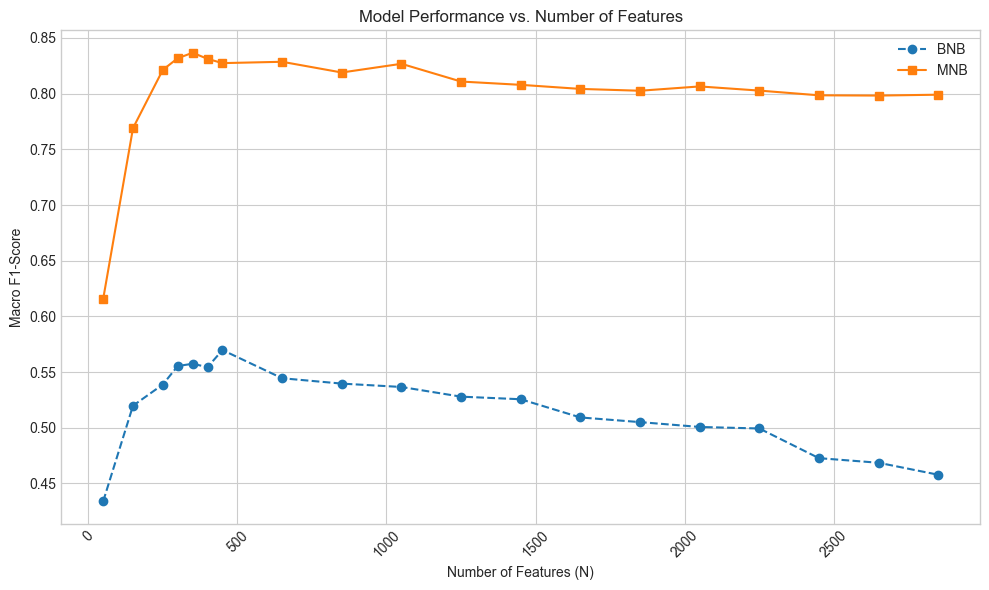


--- Model Performance (Macro F1-Score) vs. Number of Features ---
               BNB     MNB
N Features                
50          0.4340  0.6156
150         0.5198  0.7690
250         0.5389  0.8214
300         0.5555  0.8318
350         0.5575  0.8367
400         0.5545  0.8312
450         0.5698  0.8274
650         0.5445  0.8286
850         0.5397  0.8190
1050        0.5367  0.8268
1250        0.5280  0.8109
1450        0.5256  0.8079
1650        0.5093  0.8042
1850        0.5051  0.8026
2050        0.5008  0.8065
2250        0.4994  0.8027
2450        0.4728  0.7985
2650        0.4686  0.7983
2850        0.4579  0.7990


In [31]:


# load and prepare data as before
df = pd.read_csv('dataset.tsv', sep='\t')
df['document'] = df['genre'] + ' '+df['artist_name'] + ' ' + df['track_name']+ ' ' + df['lyrics']
X = df['document']
y = df['topic']

# testing with a smaller gap between 250 and 450 to more accurately approach the peak value
feature_counts = [i for i in range(50,250,100)]+[i for i in range(250,450,50)]+[i for i in range(450,3000,200)]
results = []

# run the experiment
print("Running experiments for different numbers of features...")
for n in feature_counts:
    # create vectorizer with the specified max_features
    vectorizer = CountVectorizer(
        preprocessor=best_preprocessor,
        stop_words='english',
        max_features=n
    )

    # BNB Pipeline
    bnb_pipeline = Pipeline([('vect', vectorizer), ('clf', BernoulliNB())])
    bnb_score = cross_val_score(bnb_pipeline, X, y, cv=5, scoring='f1_macro').mean()

    # MNB Pipeline
    mnb_pipeline = Pipeline([('vect', vectorizer), ('clf', MultinomialNB())])
    mnb_score = cross_val_score(mnb_pipeline, X, y, cv=5, scoring='f1_macro').mean()

    # store results
    n_label = 'All' if n is None else n
    results.append({'N Features': n_label, 'BNB': bnb_score, 'MNB': mnb_score})

# convert results to DataFrame for easy plotting and display
results_df = pd.DataFrame(results).set_index('N Features')

# get the total number of features when N is None
temp_vect = CountVectorizer(preprocessor=best_preprocessor, stop_words='english', max_features=None)
temp_vect.fit(X)
total_features = len(temp_vect.get_feature_names_out())
results_df.rename(index={'All': total_features}, inplace=True)


# plot the results
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.plot(results_df.index, results_df['BNB'], marker='o', linestyle='--', label='BNB')
plt.plot(results_df.index, results_df['MNB'], marker='s', linestyle='-', label='MNB')

plt.title('Model Performance vs. Number of Features')
plt.xlabel('Number of Features (N)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_performance.png')
plt.show()

# display the results table
print("\n--- Model Performance (Macro F1-Score) vs. Number of Features ---")
print(results_df.round(4))

For both BNB and MNB, performance increases significantly as we add more features, moving from 50 to 350. After this point, the performance begins to plateau. MNB consistently outperforms BNB across all feature counts.

Peak Performance: The MNB model achieves its peak performance with 350 features, reaching a Macro F1-Score of 0.8367. Increasing the features beyond this number does not yield any further improvement; in fact, the score got slightly worsened. The BNB model also sees its performance level off after 450 features.

Based on the experimental results, **the value for N that works best overall is 350** (for MNB).

This value is justified because it captures the point of maximum return for model performance. It achieves the highest Macro F1-Score for our superior model (MNB) before the performance curve flattens out.

## 1.5 Support Vector Machine

Here we are exploring Support Vector Machines (SVM) as the third machine learning method for the topic classification task.

### 1.5.1 Model Justification

The core idea behind SVM for classification is to find the optimal hyperplane that best separates the data points of different classes in the feature space. This "optimal" hyperplane is the one that has the maximum margin, which is the distance between the hyperplane and the nearest data points from each class.

**Suitability for Topic Classification**

Firstly, text data, when converted into a numerical format like a bag-of-words, results in a very high-dimensional feature space (where each unique word is a dimension). SVMs are known to be highly effective in these high-dimensional spaces (more at [here](https://www.ibm.com/think/topics/support-vector-machine#:~:text=SVMs%20vs%20naive%20bayes,neural%20networks)). Secondly, SVMs are less susceptible to overfitting than some other models, especially when the number of features is much larger than the number of samples.

**Implementation and Hyperparameters**

`LinearSVC` class from the scikit-learn library. This implementation is highly optimized for text classification problems. The model will be integrated into the same pipeline as our previous experiments, using the finalized preprocessing workflow:

**Features Used**: A combined document of `artist_name`, `track_name`, `genre`, and `lyrics`.

**Top-N**: A vocabulary limited to the top N=350 most frequent words.

**Hyperparameters**: LinearSVC has a main parameter C, which controls the regularization. A smaller C encourages a larger margin, even if it misclassifies more training points, while a larger C aims to classify all training examples correctly, potentially at the cost of a smaller margin. As per the assignment instructions, I will use the default settings (`C=1.0`) for this implementation. This provides a strong, standard baseline for evaluating the model's performance without extensive tuning.

**Hypothesis**: Support Vector Machine (SVM) model will outperform the Multinomial Naive Bayes (MNB) model in terms of Macro F1-Score.

The reasoning behind this hypothesis is that Naive Bayes models are built on a "naive" assumption of conditional independence between features—meaning, they assume the presence of one word in a document is unrelated to the presence of another. This is rarely true for natural language. SVMs, on the other hand, do not make this assumption. They try to find the best boundary considering all features simultaneously. This ability to handle feature interactions in high-dimensional space should, in theory, allow the SVM to build a more robust and accurate classification model. (More at [here](https://stackoverflow.com/questions/35360081/naive-bayes-vs-svm-for-classifying-text-data))